In [1]:
# # Installing Cudnn
# !apt-cache policy c

# # Install latest version
# !apt install --allow-change-held-packages libcudnn8

# # Export env variables
# !export PATH=/usr/local/cuda-11.4/bin${PATH:+:${PATH}}
# !export LD_LIBRARY_PATH=/usr/local/cuda-11.4/lib64:$LD_LIBRARY_PATH
# !export LD_LIBRARY_PATH=/usr/local/cuda-11.4/include:$LD_LIBRARY_PATH
# !export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda/extras/CUPTI/lib64

In [2]:
import os, glob, shutil, zipfile, gdown
import random, time, math, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL.Image import Image
import cv2
import onnxruntime as ort
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn import metrics as skmetrics

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers, losses

import tensorboard as tb

# metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [3]:
#original Link
# https://drive.google.com/file/d/1Y5OHRq4KPVZuvY2BnuUnsEXq9o_GuzBM/view?usp=sharing

# Global Variables
FILE_ID = "1Y5OHRq4KPVZuvY2BnuUnsEXq9o_GuzBM"
MODEL_ID = "1g7BocB3bO9l3qk8pzBmn7F32A9ib3Tf2"
dataExtractPath = "unzipLoc"
modelExtractPath = "modelUnzipLoc"
dataZipFileName = "ModelDataSet.zip"
modelZipFileName = "YoloModelV5.zip"
modelLabels = "coco.names.txt"
yoloModelName = "yolov5s.onnx"
height, width = 128, 128
BATCH_SIZE=64

In [4]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")

    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

In [11]:
def download_and_prep_dataset(FILE_ID, ZipFileName="ModelDataSet.zip", unzipLoc="unzipLoc"):
    # Download the dataset
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "dataSet/" + ZipFileName))
    extractPath = os.path.abspath(os.path.join(currentPath, unzipLoc + "/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)

    # Load the dataset
    return extractPath

def preprocess(train_data, target_height=224, target_width=224):

    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = keras.Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255),
        ]
    )

    imagePrepData = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return imagePrepData

In [6]:
# prepare the Dataset
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID, ZipFileName=dataZipFileName, unzipLoc=dataExtractPath)
dataFullPath = os.path.join(dl_ext_data_path, "selfdriving cars data", "images")
print("Data Path: ", dataFullPath)

CWD:  c:\Study\gitRepo\ComputerVision\tesla_car_detection\car_detection_yolo_model\noteBook
Data Path:  c:\Study\gitRepo\ComputerVision\tesla_car_detection\car_detection_yolo_model\noteBook\unzipLoc\selfdriving cars data\images


In [7]:
modelPath = download_and_prep_dataset(FILE_ID=MODEL_ID, ZipFileName=modelZipFileName, unzipLoc=modelExtractPath)
fullModelPath = os.path.join(modelExtractPath, yoloModelName)
fullModelLabelPath = os.path.join(modelExtractPath, modelLabels)

print("Model Path: ", fullModelPath)
print("Model labels: ", fullModelLabelPath)

CWD:  c:\Study\gitRepo\ComputerVision\tesla_car_detection\car_detection_yolo_model\noteBook
Model Path:  modelUnzipLoc\yolov5s.onnx
Model labels:  modelUnzipLoc\coco.names.txt


In [34]:
# Display the images
def displayImgfromList(imgList, imgCount):
    fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(20, 20))
    for i, img in enumerate(imgList):
        axes[i//3, i%3].imshow(img)
        axes[i//3, i%3].axis('off')
    plt.tight_layout()
    plt.show()

def preProcess(x, target_size=(224,224)):
    x_resized = tf.image.resize(x, target_size)
    x_rescaled = tf.cast(x_resized, tf.float32) / 255.0
    return x_rescaled

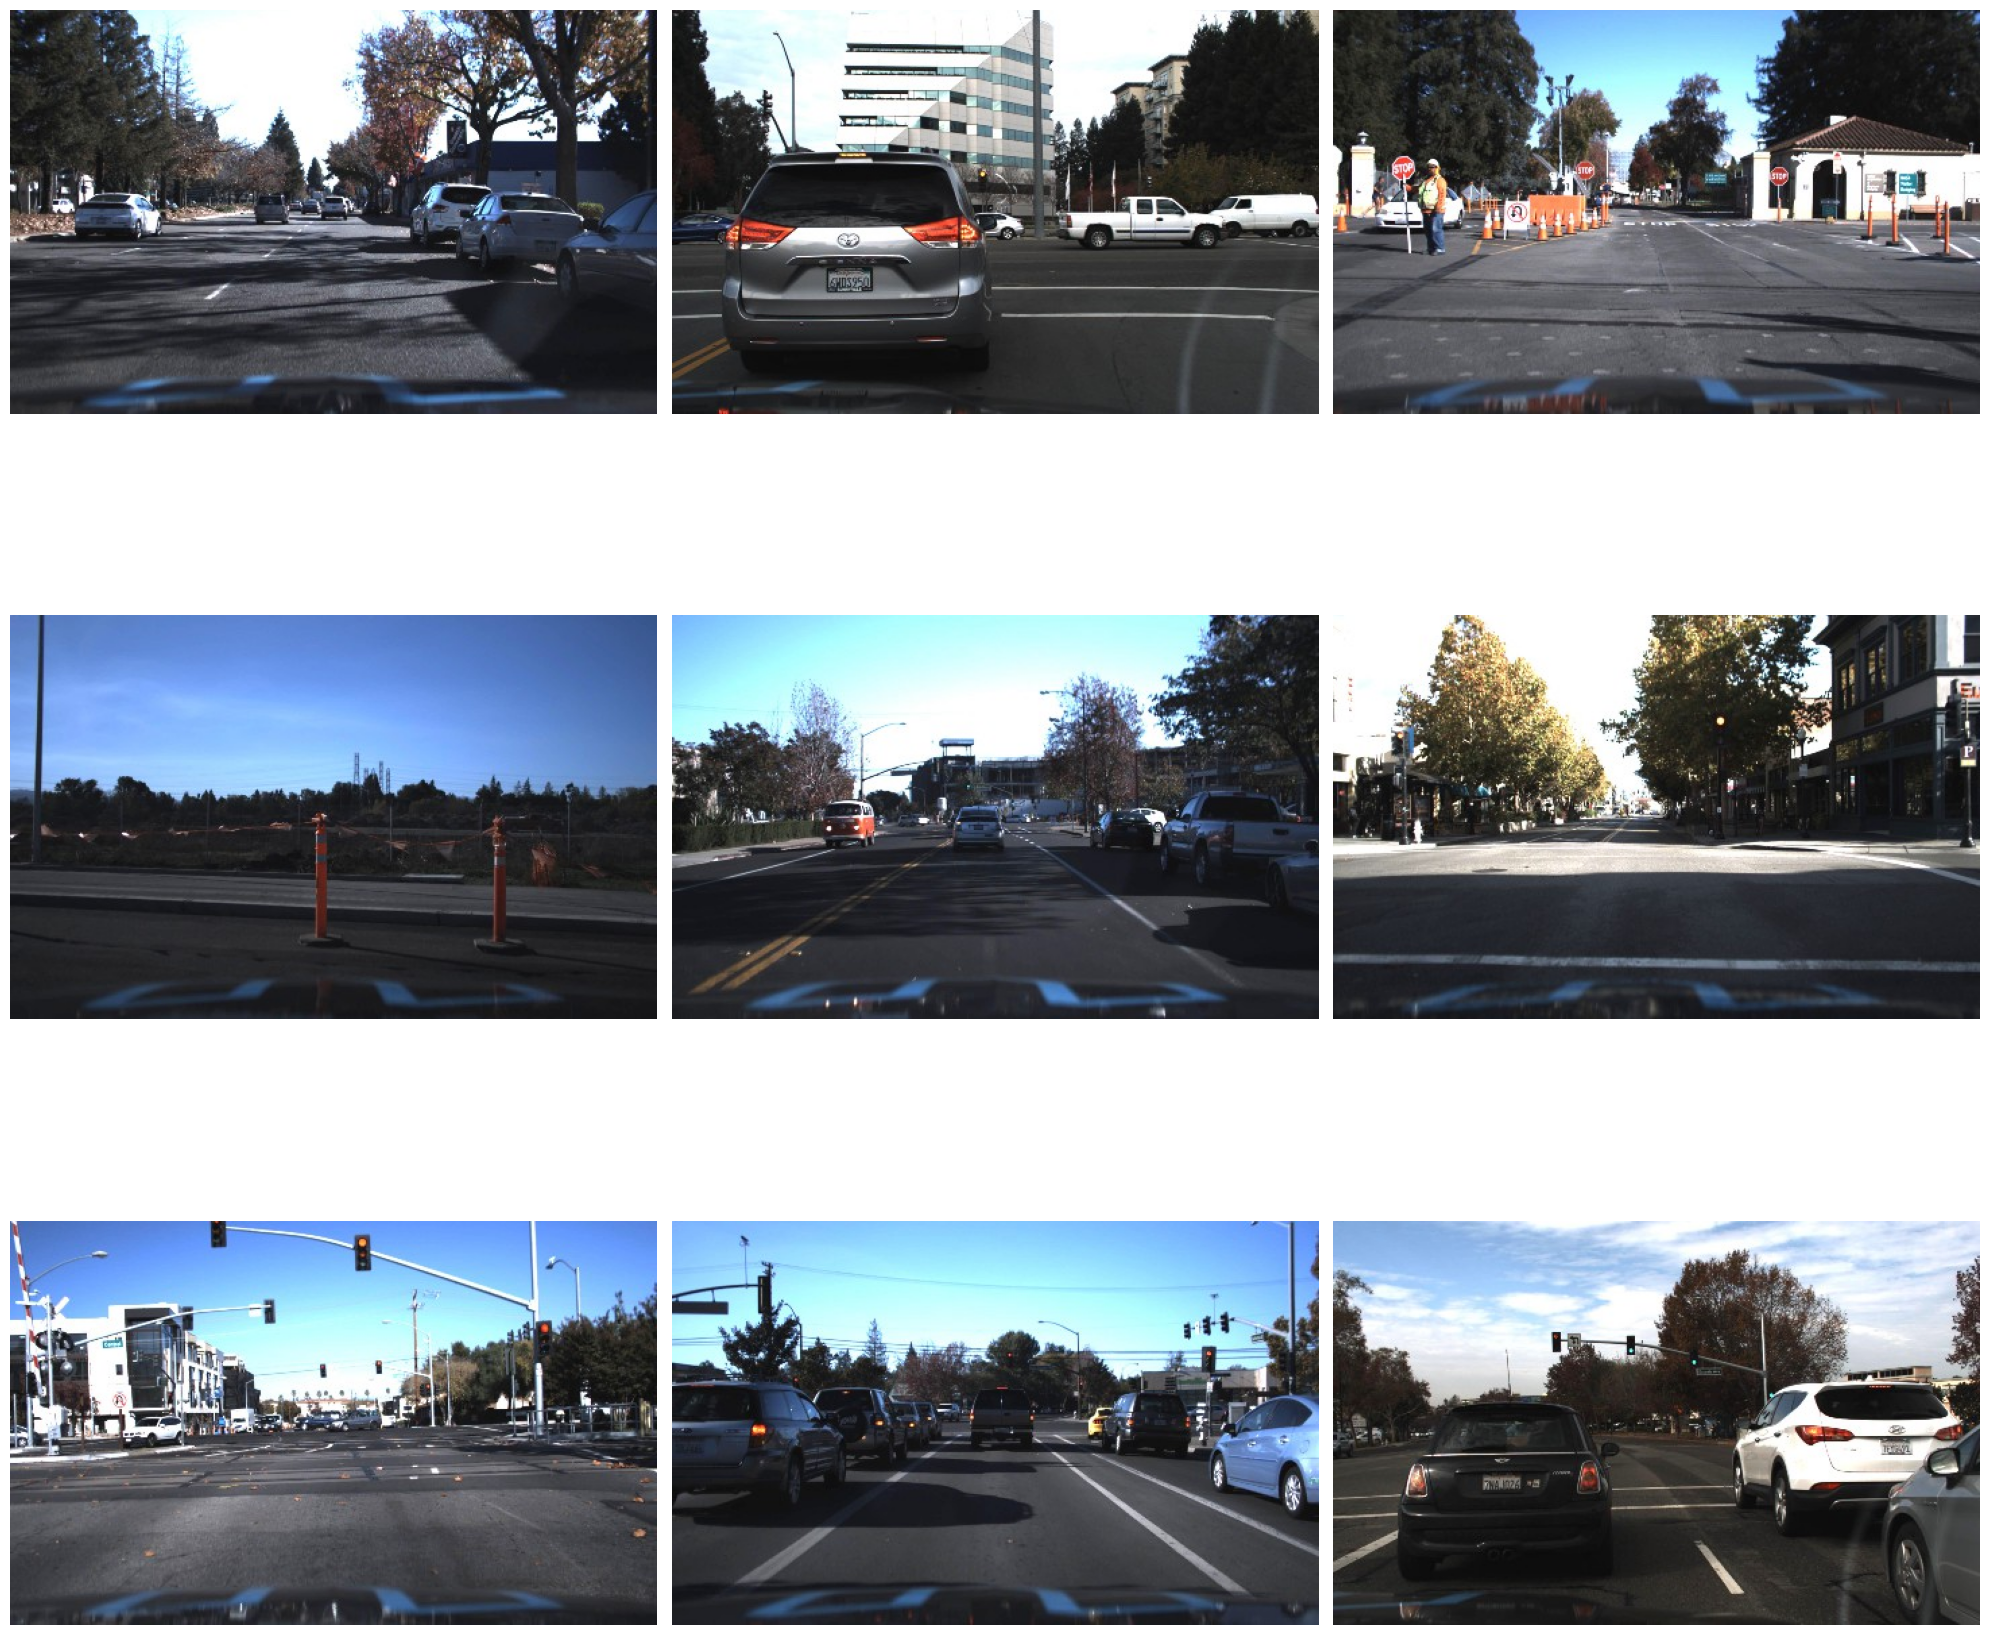

In [ ]:
imgCount = 9
imgList = []

imgFullList = glob.glob(dataFullPath + "/*.jpg")
imgSamples = random.sample(imgFullList, imgCount)

# Load the images
imgList = []  # Reset imgList to store the loaded images
for img in imgSamples:
    imgList.append(plt.imread(img))

# display test images
displayImgfromList(imgList, imgCount=imgCount)

In [35]:

# convert input list to tensor slices
XTestList = tf.data.Dataset.from_tensor_slices(imgList)
XTest = XTestList.map(lambda x: preProcess(x))

In [ ]:
def load_onnx_model(model_path):
    try:
        # Create an ONNX Runtime inference session
        session = ort.InferenceSession(model_path)
        print(f"Model loaded successfully from {model_path}")
        
        # Get model metadata
        model_inputs = session.get_inputs()
        input_names = [input.name for input in model_inputs]
        input_shapes = [input.shape for input in model_inputs]
        
        model_outputs = session.get_outputs()
        output_names = [output.name for output in model_outputs]
        
        print(f"Model input names: {input_names}")
        print(f"Model input shapes: {input_shapes}")
        print(f"Model output names: {output_names}")
        
        return session
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

def run_inference(session, preprocessed_images, confidence_threshold=0.25, iou_threshold=0.45):

    # Get input name
    input_name = session.get_inputs()[0].name
    
    # Run inference
    outputs = session.run(None, {input_name: preprocessed_images})
    
    # Process the output based on YOLOv5 format
    # YOLOv5 output is typically [batch, num_detections, 5+num_classes]
    # where 5 is for [x, y, width, height, confidence]
    detections = outputs[0]
    
    # Apply confidence threshold
    conf_mask = detections[:, 4] >= confidence_threshold
    detections = detections[conf_mask]
    
    # If no detections, return empty list
    if len(detections) == 0:
        return []
    
    # Apply NMS (Non-Maximum Suppression)
    # This is a simplified version - you might need to adjust based on your model
    boxes = []
    confidences = []
    class_ids = []
    
    for detection in detections:
        # Get box coordinates
        x, y, w, h = detection[0:4]
        
        # Convert to top-left, bottom-right format
        x1 = x - w/2
        y1 = y - h/2
        x2 = x + w/2
        y2 = y + h/2
        
        boxes.append([x1, y1, x2, y2])
        confidences.append(float(detection[4]))
        
        # Get class with highest probability
        class_id = np.argmax(detection[5:])
        class_ids.append(class_id)
    
    # Apply NMS
    indices = cv2.dnn.NMSBoxes(boxes, confidences, confidence_threshold, iou_threshold)
    
    # Prepare results
    results = []
    for i in indices:
        if isinstance(i, list):  # Handle different OpenCV versions
            i = i[0]
        
        box = boxes[i]
        confidence = confidences[i]
        class_id = class_ids[i]
        
        results.append({
            'box': box,
            'confidence': confidence,
            'class_id': class_id
        })
    
    return results

def load_class_names_from_path(labelpath=""):
    classes = None
    if os.path.exists(labelpath):
        with open(file=labelpath) as fl:
            classes = fl.read().split()
    
    return classes

# 4. Visualize detections
def visualize_detections(images, detections_list, class_names=None):
    if class_names is None:
        class_names = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 
                      'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 
                      'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 
                      'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 
                      'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 
                      'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 
                      'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 
                      'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 
                      'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 
                      'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

    colors = np.random.randint(0, 255, size=(len(class_names), 3), dtype=np.uint8)
    
    fig, axes = plt.subplots(1, len(images), figsize=(20, 10))
    if len(images) == 1:
        axes = [axes]
    
    for i, (img, detections) in enumerate(zip(images, detections_list)):
        # Convert to RGB for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Draw detections
        for det in detections:
            box = det['box']
            confidence = det['confidence']
            class_id = det['class_id']
            
            # Convert box coordinates to integers
            x1, y1, x2, y2 = map(int, box)
            
            # Get color for class
            color = tuple(map(int, colors[class_id]))
            
            # Draw bounding box
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            
            # Prepare label
            if class_id < len(class_names):
                label = f"{class_names[class_id]}: {confidence:.2f}"
            else:
                label = f"Class {class_id}: {confidence:.2f}"
            
            # Draw label background
            text_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
            cv2.rectangle(img_rgb, (x1, y1 - text_size[1] - 5), (x1 + text_size[0], y1), color, -1)
            
            # Draw label text
            cv2.putText(img_rgb, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        # Display image
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Image {i+1}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 5. Main function to run the entire pipeline
def fullModelLabelPathfullModelLabelPath(model_path, imageTensor, confidence_threshold=0.25, iou_threshold=0.45):
    # Load model
    session = load_onnx_model(model_path)
    if session is None:
        return
    
    # Run inference
    all_detections = []
    
    # Handle single image vs batch
    if len(imageTensor) == 1:
        detections = run_inference(session, imageTensor, confidence_threshold, iou_threshold)
        all_detections.append(detections)
    else:
        for i in range(len(imageTensor)):
            detections = run_inference(session, imageTensor[i:i+1], confidence_threshold, iou_threshold)
            all_detections.append(detections)
    
    classNames = load_class_names_from_path(labelpath=fullModelLabelPath)

    # Visualize detections
    visualize_detections(imageTensor, all_detections)
    
    return all_detections

In [43]:
session = load_onnx_model(model_path=fullModelPath)

Model loaded successfully from modelUnzipLoc\yolov5s.onnx
Model input names: ['images']
Model input shapes: [[1, 3, 640, 640]]
Model output names: ['output0']


In [48]:
import PIL
def preprocess_image(image_path):
    image = PIL.Image.open(image_path).resize((224, 224))  # Resize to model's input size
    image_array = np.array(image).astype('float32') / 255.0  # Normalize
    return np.expand_dims(image_array, axis=0)  # Add batch dimension

In [50]:
preprocess_image("C:\Study\gitRepo\ComputerVision\tesla_car_detection\car_detection_yolo_model\noteBook\unzipLoc\selfdriving cars data\images\1478019954186238236.jpg")

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 85-86: truncated \uXXXX escape (691243883.py, line 1)